In [161]:
from astropy.io import ascii, fits
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import cartesian_to_spherical, SkyCoord, Galactocentric

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotparams 
plotparams.default

source = '/cosma5/data/durham/dc-pick2/simulations'

In [2]:
%run ./utils.ipynb
%run ./utilsMassProfile.ipynb
%run ././utilsStream.ipynb

In [3]:

#https://ui.adsabs.harvard.edu/abs/2019A%26A...621L...2R/abstract
stars = ascii.read("HyadesData/stars.dat", readme="HyadesData/ReadMe", format="cds")
stars = stars[stars['Member'] != 'other']
stars

Source,RAdeg,DEdeg,Gmag,Member,Comment
,deg,deg,mag,,
int64,float64,float64,float64,str7,str7
2738415592529108096,0.52790198,1.26030384,16.337011,Pr_tail,-
395696646953688448,0.65309894,51.94534411,10.780623,Pr_tail,-
431526153186969856,1.47019278,63.15339413,12.036587,Pr_tail,-
386277165192421120,1.56629319,44.17454888,14.79517,Pr_tail,Contam.
393017579491591168,2.01628686,47.27540013,17.065292,Pr_tail,-
396026569162536448,2.2201788,53.21330361,10.001401,Pr_tail,-
395368374014574848,3.24031144,50.98831303,14.808033,Pr_tail,-
385502112574538624,3.82975486,43.74311559,14.398879,Pr_tail,-


In [91]:
path = source + '/Hyades2'
snap = path + '/snap.40_260.h5part'

Myr_per_Nbody = get_Myr_per_Nbody(path)
times = [648]
hyades = get_steps_at_times(path, times, run='', snap_interval=20, step_interval=0.125)

step = hyades[648]
sc = step_to_skycoord(step).icrs
sc

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(269.47795103, -24.1723663 , 7726.36678091),
     (269.46085478, -24.19998335, 7725.73799524),
     (269.46087307, -24.20008191, 7725.72983995), ...,
     (268.80163291, -25.36915426, 7699.89003422),
     (269.22905249, -24.48256411, 7709.12640415),
     (269.53226333, -24.06377177, 7771.27690242)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-3.12549254, -5.92187884, -37.34360694),
     (-3.14244383, -5.92339638, -37.29976624),
     (-3.10577757, -5.93906975, -38.06749214), ...,
     (-3.23047063, -5.91512969, -35.48883041),
     (-3.15679702, -5.93767767, -36.99329232),
     (-3.12210372, -5.90085872, -37.32468495)]>

In [5]:
step

,M,NAM,POT,Vx,Vy,Vz,X,Y,Z
0,0.012521,4924,-0.391759,-0.800600,-1.923437,-1.637563,-431.168488,740.374817,10.355700
1,1.927346,4952,-0.347646,-0.861184,-2.247880,-1.156834,-431.385834,736.057739,10.312755
2,0.039484,7508,-0.326183,-1.644459,-2.146309,-2.605522,-431.392975,736.046631,10.304166
3,0.728264,4433,-0.371154,-1.452872,-2.826820,-0.799969,-431.196655,740.043030,10.038630
4,0.280466,7000,-0.387936,-0.519141,-2.549937,-1.634451,-431.230988,740.301147,10.242332
...,...,...,...,...,...,...,...,...,...
8463,0.010979,4949,-0.011562,-6.663930,-1.066329,-1.122239,-331.168701,510.820618,15.446097
8464,0.019121,6270,-0.015467,-5.840742,-1.540038,-2.997633,-389.851044,539.205566,29.793709
8465,0.012101,632,-0.018474,-4.694876,-2.230705,0.671736,-442.351593,557.960083,0.887518
8466,0.011119,8202,-0.045216,-2.049768,-2.302326,-1.379704,-443.568268,687.532288,15.858835


In [6]:
np.sum(step['M'])

np.float32(1468.9993)

In [7]:
np.median(step['X'])

np.float32(-430.82477)

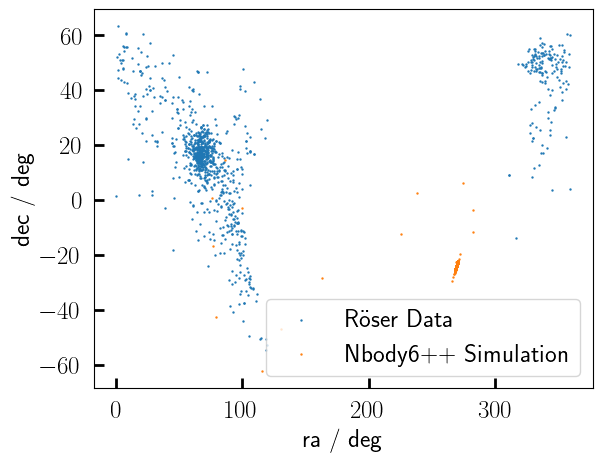

In [92]:
fig, ax = plt.subplots()

ax.scatter(stars['RAdeg'], stars['DEdeg'], label='Röser Data', s=0.5)
ax.scatter(sc.ra, sc.dec, label='Nbody6++ Simulation', s=0.5)
ax.set_xlabel('ra / deg')
ax.set_ylabel('dec / deg')
ax.legend()
plt.show()

In [9]:
c = SkyCoord(
    ra=67.985 * u.deg,
    dec=17.012 * u.deg,
    distance=47.501 * u.pc,
    pm_ra_cosdec=101.005 * u.mas/u.yr,
    pm_dec=-28.490 * u.mas/u.yr,
    radial_velocity=39.96 * u.km/u.s,
    frame='icrs'
)
c_galcen = c.transform_to(Galactocentric())
c_galcen

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in pc
    (-8166.45552331, 0.06219231, 4.13630218)
 (v_x, v_y, v_z) in km / s
    (-29.36731222, 226.4324312, 6.62834629)>

In [10]:
c_old = SkyCoord(
    ra=308.488 * u.deg,
    dec=41.217 * u.deg,
    distance=4.575 * u.pc,
    pm_ra_cosdec=-0.904 * u.mas/u.yr,
    pm_dec=-0.740 * u.mas/u.yr,
    radial_velocity=431.31 * u.km/u.s,
    frame='icrs'
)
c_galcen_old = c_old.transform_to(Galactocentric())
c_galcen_old

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in pc
    (-8121.1965063, 4.50830643, 20.84782251)
 (v_x, v_y, v_z) in km / s
    (86.16300268, 670.61819695, 12.29458118)>

In [11]:
c_galcen_old.z.to(u.kpc).value

np.float64(0.02084782250841316)

In [12]:
c_galcen_old.velocity

<CartesianDifferential (d_x, d_y, d_z) in km / s
    (86.16300268, 670.61819695, 12.29458118)>

In [13]:
c_galcen.x

<Quantity -8166.45552331 pc>

In [14]:
skydata = Table.read('HyadesData/hya.fits')
skydata

GLON,GLAT,X,Y,Z,G,Gabs,BP,RP,Distance,plx,pml,pmb,rv,NNfil,RA,DEC,U_LSR,V_LSR,W_LSR,U,V,W
float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,float64,float64,float32,float32,float32,float32,float32,float32
1.1152115127891855,-11.00585778821647,140.25174,2.7302203,-27.282225,10.610837,4.835574,10.965302,10.119104,142.9067,6.9690332,-26.038723,-15.660616,-41.82897,False,278.3306730256361,-33.20435341222343,-31.633553,-6.235019,4.8214645,-42.73355,-18.47502,-2.4285355
1.073204332474953,-27.084100898524966,133.57848,2.5023441,-68.32078,11.418191,5.5369043,11.813808,10.879746,150.05731,6.635524,-25.318586,-31.107962,-36.613747,False,297.0289666390393,-38.74486651823548,-31.228857,-6.5662932,4.2183714,-42.328857,-18.806293,-3.0316284
3.8180288946267407,30.327293399858398,93.32561,6.228176,54.71617,8.598823,3.424438,8.901656,8.167373,108.36198,9.20087,-32.748123,36.436703,-38.10736,False,242.49922495114367,-8.251619225944818,-30.02939,-7.3645062,4.163832,-41.12939,-19.604506,-3.0861678
14.666888006749637,40.71597245214302,115.68347,30.277546,102.91311,11.596744,5.6066604,12.038767,11.019327,157.76724,6.3098297,-11.269498,38.489697,-37.08427,False,239.1159918837639,4.934914140760784,-32.123714,-7.785085,4.878064,-43.223713,-20.025085,-2.3719358
11.164328014084695,32.96220904921506,36.72225,7.2474446,24.272625,10.545073,7.297826,11.321008,9.714758,44.611763,22.386738,-44.750347,119.46454,-39.40965,False,244.07677376429922,-1.6517056346660421,-32.993595,-6.1086273,7.005394,-44.093594,-18.348627,-0.24460605
105.17388659409693,7.343920763683693,-36.871372,135.95406,18.155012,12.739021,6.977116,13.436145,11.952944,142.0303,7.011937,61.296413,-0.16876882,-7.368047,False,329.1945937030987,64.015941659149,-26.822481,-5.601285,6.195482,-37.92248,-17.841286,-1.0545183
104.97868177749288,53.806133904763605,-26.992699,100.88826,142.72685,12.8284025,6.590306,13.445687,12.097578,176.85588,5.6255293,52.981857,5.1481824,-7.047011,False,214.35968611669534,60.221818998917996,-29.833845,-6.62537,4.1116567,-40.933846,-18.86537,-3.1383433
106.5055906995396,-21.10715524058887,-10.185438,34.373146,-13.83869,11.749179,8.825901,12.900521,10.706181,38.42871,25.99329,250.60028,-21.210913,-4.981072,True,352.9533801426931,39.21137435199707,-30.95512,-6.519642,5.438996,-42.05512,-18.759642,-1.8110042
103.64360658670999,-12.375101823527713,-17.116508,70.5163,-15.92116,10.559961,6.205309,11.107695,9.901298,74.290016,13.432034,124.19336,-8.178193,-8.508213,True,345.0273165334489,46.28543794686336,-29.297047,-6.7526345,6.2602096,-40.397045,-18.992634,-0.9897905


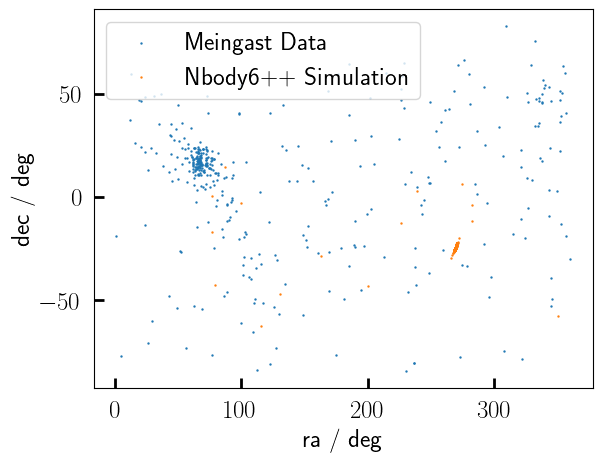

In [93]:
fig, ax = plt.subplots()

ax.scatter(skydata['RA'], skydata['DEC'], label='Meingast Data', s=0.5)
ax.scatter(sc.ra, sc.dec, label='Nbody6++ Simulation', s=0.5)
ax.set_xlabel('ra / deg')
ax.set_ylabel('dec / deg')
ax.legend()
plt.show()

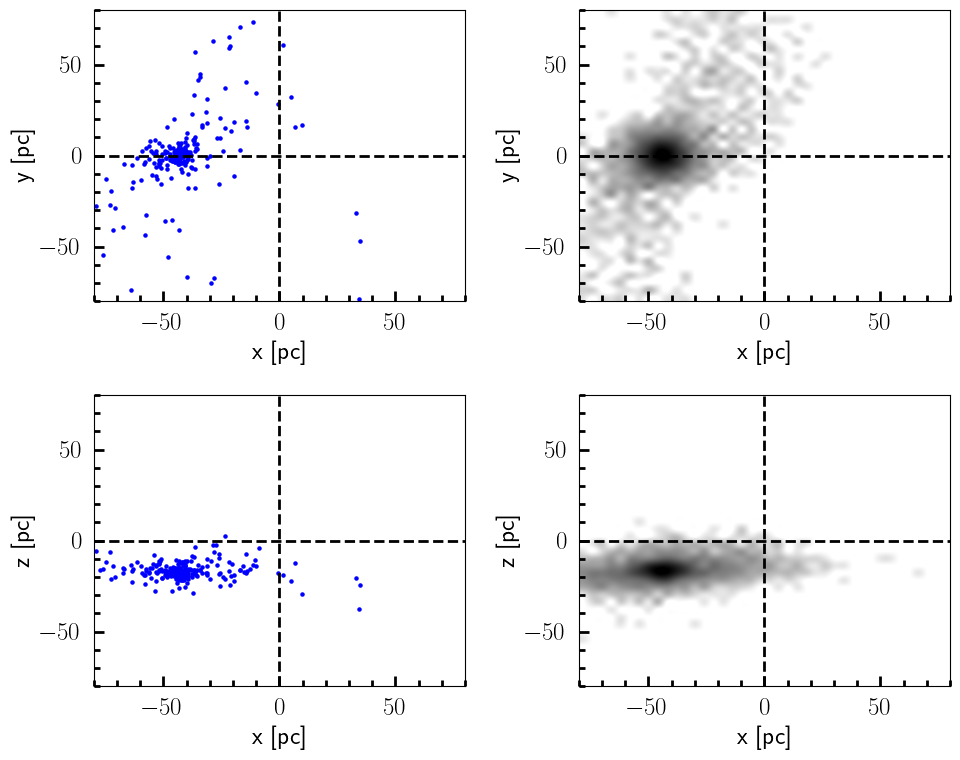

In [107]:
plotparams.default()

#hy_pos = np.array([-8166.45552331, 0.06219231, 4.13630218])
hy_pos = np.array([-44.26, 0.31, -16.89]) # pc
cmap   = "gray_r"

scale  = 80


X1     = step['X']
X2     = step['Y']
X3     = step['Z']
Mass   = step['M']
Pos    = np.column_stack((X1,X2,X3))

centre = np.array(shrinking_sphere(X1, X2, X3, Mass))
Pos  -= centre
Pos  += hy_pos

# Hyades data

hdu  = fits.open("HyadesData/hya.fits")
#hdu  = fits.open("../Data/stream.fits")
X    = hdu[1].data["X"]
Y    = hdu[1].data["Y"]
Z    = hdu[1].data["Z"]
try:
    nnf  = hdu[1].data["NNfil"]
    mask = np.where(nnf == True)[0]
    X    = X[mask]
    Y    = Y[mask]
    Z    = Z[mask]
except KeyError:
    print("Note: Dataset NNfil was not found.")

# Histogram

nbin1 = 40
H, xedges, yedges = np.histogram2d(Pos[:,0], Pos[:,1],
                                   bins = (nbin1,nbin1), 
                                   range=[[-scale, scale],[-scale,scale]])
H = np.rot90(H)
H = np.flipud(H)
extent = [yedges[0], yedges[-1], xedges[0], xedges[-1]]
logH = np.log10(1.+H)

H1, xedges, yedges = np.histogram2d(Pos[:,0], Pos[:,2],
                                    bins = (nbin1,nbin1),
                                    range=[[-scale, scale],[-scale,scale]])
H1 = np.rot90(H1)
H1 = np.flipud(H1)
extent = [yedges[0], yedges[-1], xedges[0], xedges[-1]]
logH1 = np.log10(1.+H1)

# Figure

plt.close("all")
fig  = plt.figure(figsize = (10, 8))
ax1  = fig.add_subplot(221)
ax2  = fig.add_subplot(222)
ax1.set_xlabel(r"x [pc]")
ax1.set_ylabel(r"y [pc]")
ax2.set_xlabel(r"x [pc]")
ax2.set_ylabel(r"y [pc]")
ax1.minorticks_on()
ax2.minorticks_on()
ax1.set_xlim(-scale, scale)
ax1.set_ylim(-scale, scale)
ax2.set_xlim(-scale, scale)
ax2.set_ylim(-scale, scale)

ax3  = fig.add_subplot(223)
ax4  = fig.add_subplot(224)
ax3.set_xlabel(r"x [pc]")
ax3.set_ylabel(r"z [pc]")
ax4.set_xlabel(r"x [pc]")
ax4.set_ylabel(r"z [pc]")
ax3.minorticks_on()
ax4.minorticks_on()
ax3.set_xlim(-scale, scale)
ax3.set_ylim(-scale, scale)
ax4.set_xlim(-scale, scale)
ax4.set_ylim(-scale, scale)

ax1.scatter(X, Y, marker = "o", color = "b", s = 5)
#ax2.scatter(Pos[:,0], Pos[:,1], marker = ".", color = "grey", s = 2, alpha = 0.6)
ax2.imshow(logH, origin = "lower", interpolation = "spline36", cmap = cmap,\
               extent = [-scale, scale, -scale, scale], aspect = "auto")
ax1.axhline(y=0, color = "k", ls = "--", lw = 2.0)
ax2.axhline(y=0, color = "k", ls = "--", lw = 2.0)
ax1.axvline(x=0, color = "k", ls = "--", lw = 2.0)
ax2.axvline(x=0, color = "k", ls = "--", lw = 2.0)

ax3.scatter(X, Z, marker = "o", color = "b", s = 5)
#ax4.scatter(Pos[:,0], Pos[:,2], marker = ".", color = "grey", s = 2, alpha = 0.6)
ax4.imshow(logH1, origin = "lower", interpolation = "spline36", cmap = cmap,\
               extent = [-scale, scale, -scale, scale], aspect = "auto")
ax3.axhline(y=0, color = "k", ls = "--", lw = 2.0)
ax4.axhline(y=0, color = "k", ls = "--", lw = 2.0)
ax3.axvline(x=0, color = "k", ls = "--", lw = 2.0)
ax4.axvline(x=0, color = "k", ls = "--", lw = 2.0)

plt.tight_layout()
plt.show()





In [203]:
# Following 2 cells are adapted from code provided by Sownak Bose

hy_pos = np.array([-44.26, 0.31, -16.89]) # pc
cmap   = "gray_r"

scale  = 300


X1     = step['X']
X2     = step['Y']
X3     = step['Z']
Mass   = step['M']
Pos    = np.column_stack((X1,X2,X3))

centre = np.array(shrinking_sphere(X1, X2, X3, Mass))
Pos  -= centre
Pos  += hy_pos

# Hyades data

hdu  = fits.open("HyadesData/hya.fits")
#hdu  = fits.open("../Data/stream.fits")
X    = hdu[1].data["X"]
Y    = hdu[1].data["Y"]
Z    = hdu[1].data["Z"]
try:
    nnf  = hdu[1].data["NNfil"]
    mask = np.where(nnf == True)[0]
    X    = X[mask]
    Y    = Y[mask]
    Z    = Z[mask]
except KeyError:
    print("Note: Dataset NNfil was not found.")

# Histogram

nbin1 = 40
H, xedges, yedges = np.histogram2d(Pos[:,0], Pos[:,1],
                                   bins = (nbin1,nbin1), 
                                   range=[[-scale, scale],[-scale,scale]])
H = np.rot90(H)
H = np.flipud(H)
extent = [yedges[0], yedges[-1], xedges[0], xedges[-1]]
logH = np.log10(1.+H)

H1, xedges, yedges = np.histogram2d(Pos[:,0], Pos[:,2],
                                    bins = (nbin1,nbin1),
                                    range=[[-scale, scale],[-scale,scale]])
H1 = np.rot90(H1)
H1 = np.flipud(H1)
extent = [yedges[0], yedges[-1], xedges[0], xedges[-1]]
logH1 = np.log10(1.+H1)

/tmp/ipykernel_2464157/1922000029.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(-99999999, 0, "-", color='gray', label='Nbody6++ Simulation', linestyle='', marker='s')


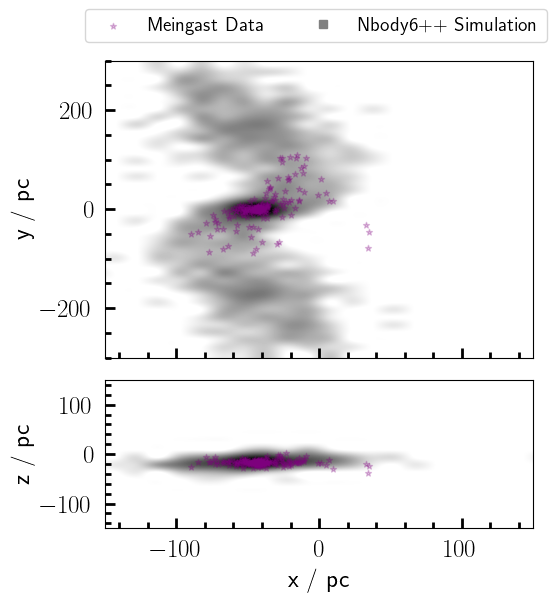

In [212]:


fig, axes = plt.subplots(2, figsize=(6,6), gridspec_kw={'height_ratios': [2, 1]})
ax1, ax2 = axes

ax1.set_ylabel(r"y / pc")
ax2.set_xlabel(r"x / pc")
ax2.set_ylabel(r"z / pc")
ax1.minorticks_on()
ax1.set_xticklabels([])
ax2.minorticks_on()


ax1.scatter(X, Y, marker = "*", color = "purple", s = 20, alpha = 0.25, label='Meingast Data')
ax1.imshow(logH, origin = "lower", interpolation = "spline36", cmap = cmap,\
               extent = [-scale, scale, -scale, scale], aspect = "auto")


ax2.scatter(X, Z, marker = "*", color = "purple", s = 20, alpha = 0.25)
ax2.imshow(logH1, origin = "lower", interpolation = "spline36", cmap = cmap,\
               extent = [-scale, scale, -scale, scale], aspect = "auto")

#far away friend to help with legend (imshow doesnt appear in it)
ax1.plot(-99999999, 0, "-", color='gray', label='Nbody6++ Simulation', linestyle='', marker='s')

#ax1.axhline(y=0, color = "k", ls = "--", lw = 1.0)
#ax1.axvline(x=0, color = "k", ls = "--", lw = 1.0)
#ax2.axhline(y=0, color = "k", ls = "--", lw = 1.0)
#ax2.axvline(x=0, color = "k", ls = "--", lw = 1.0)

ax1.set_xlim(-scale/2, scale/2)
ax1.set_ylim(-scale, scale)
ax2.set_xlim(-scale/2, scale/2)
ax2.set_ylim(-scale/2, scale/2)


handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.56, 0.95), fontsize=14)

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.savefig('Images/HyadesValidate', bbox_inches='tight')
plt.show()

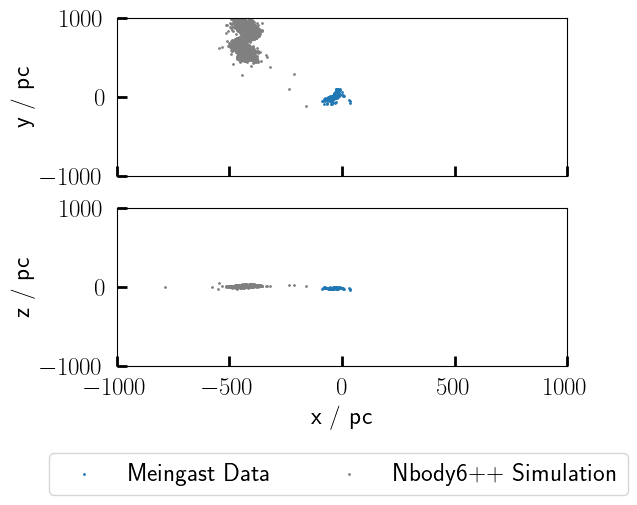

In [147]:
scale = 1000
fig, axes = plt.subplots(2)

ax = axes[0]
ax.scatter(X,Y, marker = "o", color = "tab:blue", s = 1, label='Meingast Data')
ax.scatter(X1,X2, marker = "o", color = "gray", s = 1, label='Nbody6++ Simulation')
ax.set_ylabel('y / pc')
ax.set_xlim(-scale,scale)
ax.set_ylim(-scale,scale)
ax.set_xticklabels([])

ax = axes[1]
ax.scatter(X,Z, marker = "o", color =  "tab:blue", s = 1, label='Meingast Data')
ax.scatter(X1,X3, marker = "o", color = "gray", s = 1, label='Nbody6++ Simulation')
ax.set_xlabel('x / pc')
ax.set_ylabel('z / pc')
ax.set_xlim(-scale,scale)
ax.set_ylim(-scale,scale)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.56, -0.1))

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()